In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv("/content/ai4i2020.csv")

# Display first 5 rows
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

Task 1: Simple Linear Regression


Simple Linear Regression MSE: 2.1691240317336407


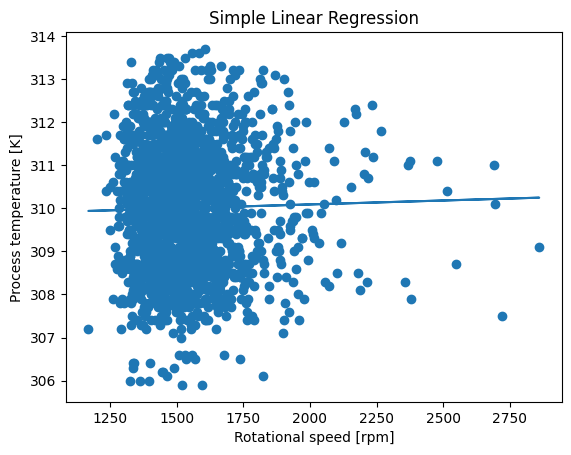

In [4]:
# Input feature
X = df[['Rotational speed [rpm]']]

# Target column
y = df['Process temperature [K]']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict values
y_pred = model.predict(X_test)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

print("Simple Linear Regression MSE:", mse)

# Plot line of best fit
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)

plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Process temperature [K]")
plt.title("Simple Linear Regression")

plt.show()

Task 2: Multivariable Regression

In [5]:
# Multiple input features
X = df[
    [
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]',
        'Air temperature [K]'
    ]
]

# Target column
y = df['Process temperature [K]']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
multi_model = LinearRegression()

# Train model
multi_model.fit(X_train, y_train)

# Predict values
y_pred_multi = multi_model.predict(X_test)

# Calculate MSE
multi_mse = mean_squared_error(y_test, y_pred_multi)

print("Multivariable Regression MSE:", multi_mse)

Multivariable Regression MSE: 0.5298708765361675


Task 3: Save Multivariable Regression Model

In [6]:
import joblib

# Save model
joblib.dump(multi_model, "temperature_model.pkl")

print("Model saved successfully")

Model saved successfully


In [7]:
import joblib
import pandas as pd

# Load saved model
model = joblib.load("temperature_model.pkl")

# New machine reading
new_data = pd.DataFrame({
    'Rotational speed [rpm]': [1500],
    'Torque [Nm]': [40],
    'Tool wear [min]': [120],
    'Air temperature [K]': [300]
})

# Predict temperature
prediction = model.predict(new_data)

print("Predicted Temperature:", prediction[0])

Predicted Temperature: 310.00269898207705


Task 4 — One Hot Encoding

In [8]:
# Select columns
df2 = df[
    [
        'Type',
        'Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]',
        'Machine failure'
    ]
]

# One Hot Encoding
encoded_df = pd.get_dummies(df2, columns=['Type'], drop_first=True)

print(encoded_df.head())

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  Type_L  Type_M  
0         42.8                0                0   False    True  
1         46.3                3                0    True   False  
2         49.4                5                0    True   False  
3         39.5                7                0    True   False  
4         40.0                9                0    True   False  


Task 5 — Train-Test Split

In [9]:
# Features
X = encoded_df.drop('Process temperature [K]', axis=1)

# Target
y = encoded_df['Process temperature [K]']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
split_model = LinearRegression()
split_model.fit(X_train, y_train)

# Predict
y_pred = split_model.predict(X_test)

# MSE
mse = mean_squared_error(y_test, y_pred)

print("Train-Test Split Model MSE:", mse)

Train-Test Split Model MSE: 0.5261170575446612


Task 6 — Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# Features
X = encoded_df.drop('Machine failure', axis=1)

# Target
y = encoded_df['Machine failure']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

# Predict
y_pred = log_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Accuracy: 0.974
Confusion Matrix:
[[1930    9]
 [  43   18]]
